We are going to scrape data on most recent Bitcoin transactions, and analyze the historical data to determine which mining pool would be best to consider joining. First, I will load data from a given timeframe into a list of .tsv files.

In [58]:
"""
https://gz.blockchair.com/bitcoin/blocks/

Access .tsv files containing daily block transactions
Count most prominent miners / companies

@author: sohan
"""

from bs4 import BeautifulSoup
import time
import random
from urllib.request import urlopen
import requests
import pandas as pd
import gzip
import io
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt

start_date = datetime.strptime("2025-01-01", "%Y-%m-%d")
end_date = datetime.strptime("2025-06-05", "%Y-%m-%d")

address = "https://gz.blockchair.com/bitcoin/blocks/"
page = urlopen(address)
soup = BeautifulSoup(page, "html.parser")

all_links = []
for link in soup.find_all('a'):
    href = link.get('href')
    if href and href.endswith('.tsv.gz'):
        # get date
        date = href.split('_')[-1].replace('.tsv.gz', '')
        try:
            file_date = datetime.strptime(date, '%Y%m%d')
        except ValueError:
            continue

        if start_date <= file_date <= end_date:
            all_links.append((file_date, address + href))

print(all_links)


[(datetime.datetime(2025, 1, 1, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250101.tsv.gz'), (datetime.datetime(2025, 1, 2, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250102.tsv.gz'), (datetime.datetime(2025, 1, 3, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250103.tsv.gz'), (datetime.datetime(2025, 1, 4, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250104.tsv.gz'), (datetime.datetime(2025, 1, 5, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250105.tsv.gz'), (datetime.datetime(2025, 1, 6, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250106.tsv.gz'), (datetime.datetime(2025, 1, 7, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250107.tsv.gz'), (datetime.datetime(2025, 1, 8, 0, 0), 'https://gz.blockchair.com/bitcoin/blocks/blockchair_bitcoin_blocks_20250108.tsv.gz'),

Now, once the data has been loaded, I will compile a few different statistics: total number of blocks won over the entire period, monthly block wins, daily block wins, and largest number of consecutive blocks won by each mining pool.

           Miner  Number of Blocks Won
Foundry USA Pool                  7151
         AntPool                  4183
         Unknown                  3822
          ViaBTC                  3155
          F2Pool                  2413
      SpiderPool                   933
         Binance                   396
       SlushPool                   295
       SBICrypto                   259
          Poolin                    96
     Solo CKPool                     5


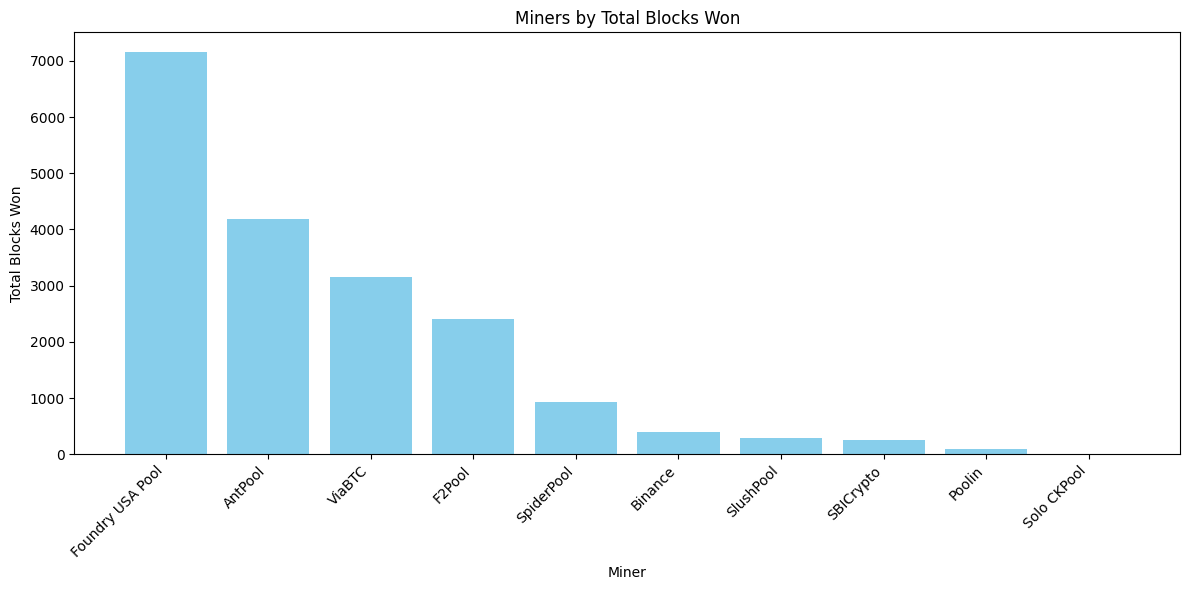

           Miner   Month  Blocks Won
         AntPool 2025-01         783
         AntPool 2025-02         772
         AntPool 2025-03         841
         AntPool 2025-04         807
         AntPool 2025-05         873
         AntPool 2025-06         107
         Binance 2025-01          70
         Binance 2025-02          58
         Binance 2025-03          98
         Binance 2025-04          84
         Binance 2025-05          74
         Binance 2025-06          12
          F2Pool 2025-01         523
          F2Pool 2025-02         450
          F2Pool 2025-03         459
          F2Pool 2025-04         412
          F2Pool 2025-05         499
          F2Pool 2025-06          70
Foundry USA Pool 2025-01        1481
Foundry USA Pool 2025-02        1272
Foundry USA Pool 2025-03        1455
Foundry USA Pool 2025-04        1373
Foundry USA Pool 2025-05        1379
Foundry USA Pool 2025-06         191
          Poolin 2025-01          20
          Poolin 2025-02          22
 

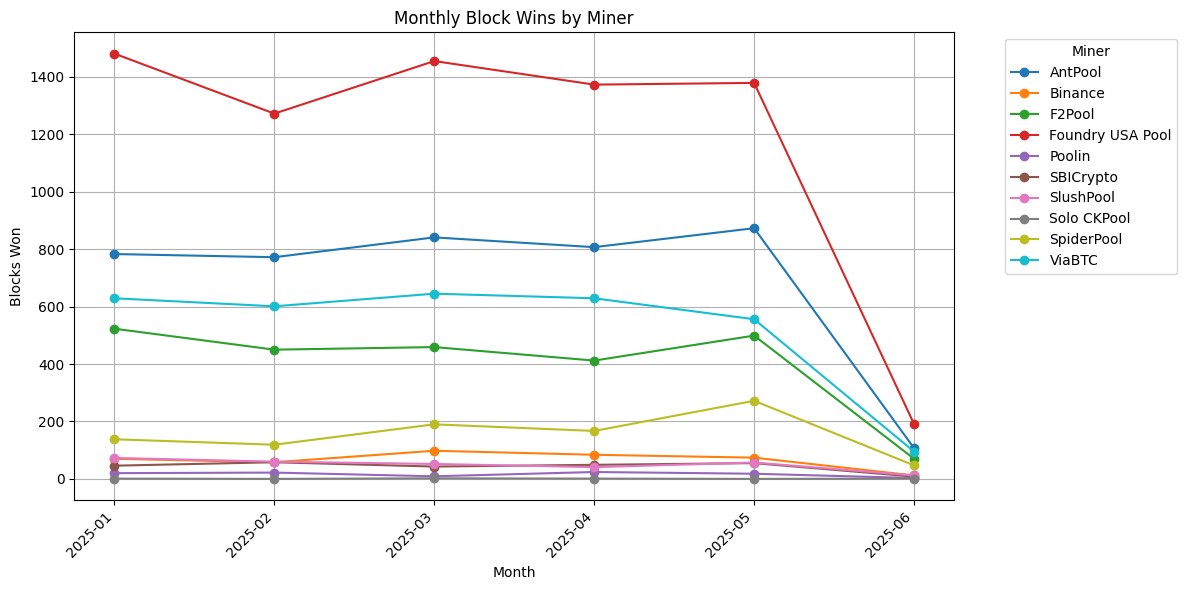

In [59]:
miner_counts = {}
monthly_counts = defaultdict(lambda: defaultdict(int))

all_rows = []

for file_date, file_url in all_links:
    resp = requests.get(file_url)
    time.sleep(random.uniform(1, 2))
    
    with gzip.open(io.BytesIO(resp.content), mode='rt') as f:
        df = pd.read_csv(f, sep='\t', usecols=["fee_total", "guessed_miner"])
        df["Date"] = pd.to_datetime(file_date)
        all_rows.append(df)

        # extract date
        month = file_date.strftime("%Y-%m")

        for miner in df["guessed_miner"].dropna():
            miner_counts[miner] = miner_counts.get(miner, 0) + 1
            monthly_counts[miner][month] += 1

all_df = pd.concat(all_rows, ignore_index=True)

miner_df = pd.DataFrame(list(miner_counts.items()), columns=["Miner", "Number of Blocks Won"])
miner_df = miner_df.sort_values(by="Number of Blocks Won", ascending=False)

monthly_rows = []
for miner, month_dict in monthly_counts.items():
    for month, count in month_dict.items():
        monthly_rows.append({"Miner": miner, "Month": month, "Blocks Won": count})
monthly_df = pd.DataFrame(monthly_rows)
monthly_df = monthly_df.sort_values(by=["Miner", "Month"])

print(miner_df.to_string(index=False))
filtered_miner_df = miner_df[miner_df["Miner"] != "Unknown"]

plt.figure(figsize=(12, 6))
plt.bar(filtered_miner_df["Miner"], filtered_miner_df["Number of Blocks Won"], color='skyblue')
plt.xlabel("Miner")
plt.ylabel("Total Blocks Won")
plt.title("Miners by Total Blocks Won")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(monthly_df.to_string(index=False))
filtered_monthly_df = monthly_df[monthly_df["Miner"] != "Unknown"]
pivot = filtered_monthly_df.pivot(index="Month", columns="Miner", values="Blocks Won").fillna(0)

pivot = pivot.sort_index()

plt.figure(figsize=(12, 6))
for miner in pivot.columns:
    plt.plot(pivot.index, pivot[miner], marker='o', label=miner)

plt.xlabel("Month")
plt.ylabel("Blocks Won")
plt.title("Monthly Block Wins by Miner")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Miner", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


In [60]:
all_df = all_df.sort_values(by="Date").reset_index(drop=True)

curr_streaks = defaultdict(int)
max_streaks = defaultdict(int)
prev_miner = None

for index, row in all_df.iterrows():
    miner = row["guessed_miner"]

    if miner == prev_miner:
        curr_streaks[miner] += 1
    else:
        if prev_miner is not None:
            curr_streaks[prev_miner] = 0
        curr_streaks[miner] = 1
    
    max_streaks[miner] = max(max_streaks[miner], curr_streaks[miner])
    prev_miner = miner

streaks_df = pd.DataFrame(list(max_streaks.items()), columns=["Miner", "Max Consecutive Blocks Won"])
streaks_df = streaks_df[streaks_df["Miner"] != "Unknown"]
streaks_df = streaks_df.sort_values(by="Max Consecutive Blocks Won", ascending=False)
print(streaks_df.to_string(index=False))

           Miner  Max Consecutive Blocks Won
Foundry USA Pool                           7
          ViaBTC                           5
         AntPool                           5
          F2Pool                           4
       SlushPool                           3
      SpiderPool                           3
         Binance                           2
       SBICrypto                           2
          Poolin                           1
     Solo CKPool                           1


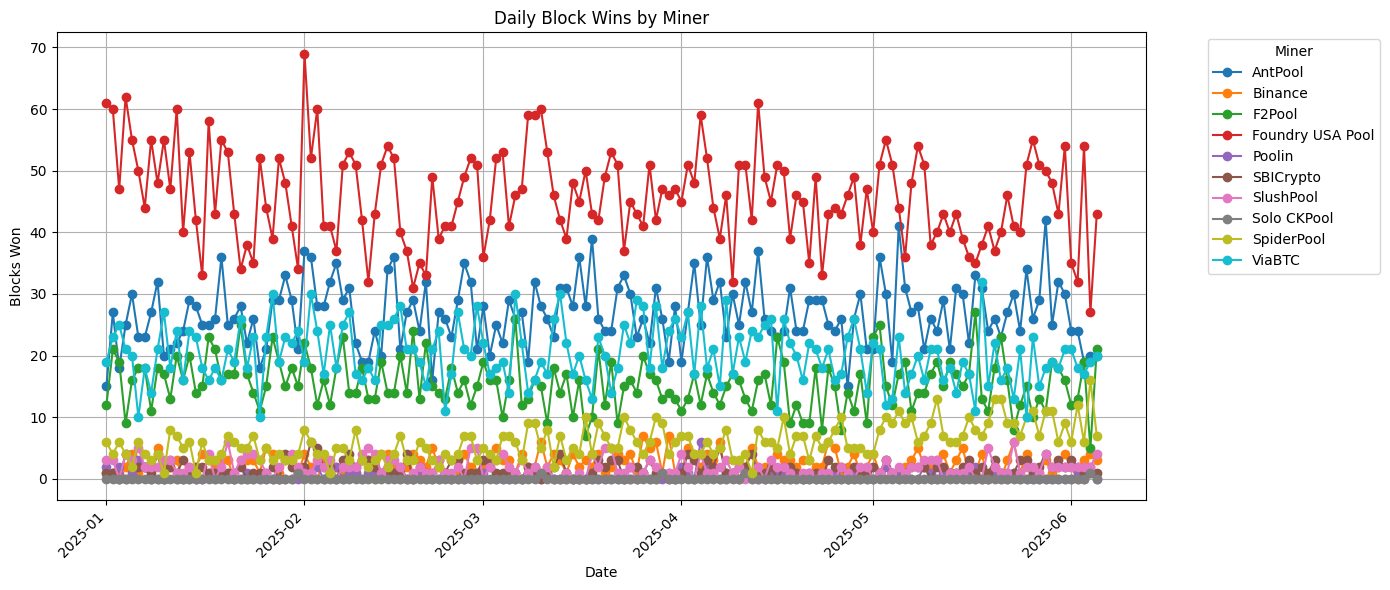

In [61]:
filtered_all_df = all_df[all_df["guessed_miner"] != "Unknown"]

daily_counts = filtered_all_df.groupby([filtered_all_df["Date"].dt.date, "guessed_miner"]).size().reset_index(name="Blocks Won")
daily_counts.rename(columns={"guessed_miner": "Miner", "Date": "Day"}, inplace=True)

# pivot: rows = Day, columns = Miner
pivot = daily_counts.pivot(index="Day", columns="Miner", values="Blocks Won").fillna(0)
pivot = pivot.sort_index()

plt.figure(figsize=(14, 6))
for miner in pivot.columns:
    plt.plot(pivot.index, pivot[miner], marker='o', label=miner)

plt.xlabel("Date")
plt.ylabel("Blocks Won")
plt.title("Daily Block Wins by Miner")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Miner", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

At this point, I will now consider the potential total payout over a day if joining one of these pools. I will use the following equation, which follows the Full-Pay-Per-Share (FPPS) mining pool structure.

$$\text{Monthly FPPS Reward} = (\frac{H_m}{H_p}) \cdot B_m \cdot (R_b + R_t) \cdot (1-f)$$

Where:
- $ H_m $ = our miner's hashrate (TH/s)
- $ H_p $ = total pool hashrate (TH/s)
- $ R_b $ = current block reward (3.125 BTC/block)
- $ R_t $ = average transaction fee per block (BTC/block)
- $ B_m $ = number of blocks mined per month
- $ f $ = pool fee

Our miner's hashrate (two projected hashrates to consider):
- Option 1: 91960 TH/s
- Option 2: 56472 TH/s

In [81]:
# Mining pool statistics (manually inputted)
miner_statistics = {
    "AntPool": {
        "hashrate": 168000000,
        "fee": 0.04
    },
    "Binance": {
        "hashrate": 58350000,
        "fee": 0.04
    },
    "F2Pool": {
        "hashrate": 91650000,
        "fee": 0.04
    },
    "Foundry USA Pool": {
        "hashrate": 187540000,
        "fee": 0.035,
    },
    "Poolin": {
        "hashrate": 2090000,
        "fee": 0.04,
    },
    "SBICrypto": {
        "hashrate": 11490000,
        "fee": 0.015,
    },
    "SlushPool": {
        "hashrate": 12050000,
        "fee": 0.025,
    },
    "Solo CKPool": {
        "hashrate": 113000,
        "fee": 0.02,
    },
    "SpiderPool": {
        "hashrate": 56760000,
        "fee": 0.04,
    },
    "ViaBTC": {
        "hashrate": 119580000,
        "fee": 0.04,
    }
}

# getting average transaction fees each month
all_df["Month"] = all_df["Date"].dt.to_period("M").astype(str)
all_df["fee_btc"] = all_df["fee_total"] / 1e8

R_t = all_df.groupby("Month")["fee_btc"].mean()
R_t_df = R_t.reset_index()
R_t_df.columns = ["Month", "Avg Transaction Fee (BTC)"]

# Inputs
miner_hashrates = {
    "91,960 TH/s": 91960,
    "56,472 TH/s": 56472,
}
R_b = 3.125

months_to_include = ["2025-01", "2025-02", "2025-03", "2025-04", "2025-05"]
fpps_df_base = filtered_monthly_df[filtered_monthly_df["Month"].isin(months_to_include)].copy()

fpps_df_base = fpps_df_base.merge(R_t_df, on="Month", how="left")
all_results = []

for label, H_m in miner_hashrates.items():
    fpps_df = fpps_df_base.copy()
    fpps_df["FPPS Reward per Month"] = 0.0

    for i, row in fpps_df.iterrows():
        miner_name = row["Miner"]
        B_m = row["Blocks Won"]
        R_fee = row["Avg Transaction Fee (BTC)"]

        if miner_name in miner_statistics:
            H_p = miner_statistics[miner_name]["hashrate"] + H_m    # include our hashrate if we join the pool
            f = miner_statistics[miner_name]["fee"]
            R_block = R_b + R_fee

            reward = (H_m / H_p) * B_m * R_block * (1 - f)
            fpps_df.at[i, "FPPS Reward per Month"] = reward

    reward_table = fpps_df.pivot(index='Month', columns='Miner', values='FPPS Reward per Month')
    reward_table.columns = pd.MultiIndex.from_product([[label], reward_table.columns])
    all_results.append(reward_table)

fpps_table = pd.concat(all_results, axis=1).round(6)
fpps_table = fpps_table.fillna(0)

print(fpps_table)


        91,960 TH/s                                                           \
Miner       AntPool   Binance    F2Pool Foundry USA Pool    Poolin SBICrypto   
Month                                                                          
2025-01    1.304004  0.335303  1.595871         2.221101  2.565944  1.140787   
2025-02    1.284253  0.277513  1.371591         1.905533  2.819396  1.436783   
2025-03    1.397515  0.468391  1.397501         2.177308  1.152135  1.064042   
2025-04    1.342113  0.401806  1.255427         2.056280  3.074871  1.213505   
2025-05    1.451979  0.353997  1.520638         2.065412  2.306316  1.362193   

                                                   56,472 TH/s            \
Miner   SlushPool Solo CKPool SpiderPool    ViaBTC     AntPool   Binance   
Month                                                                      
2025-01  1.709352    1.394279   0.679513  1.471371    0.800949  0.206032   
2025-02  1.403382    0.000000   0.585304  1.404308    0

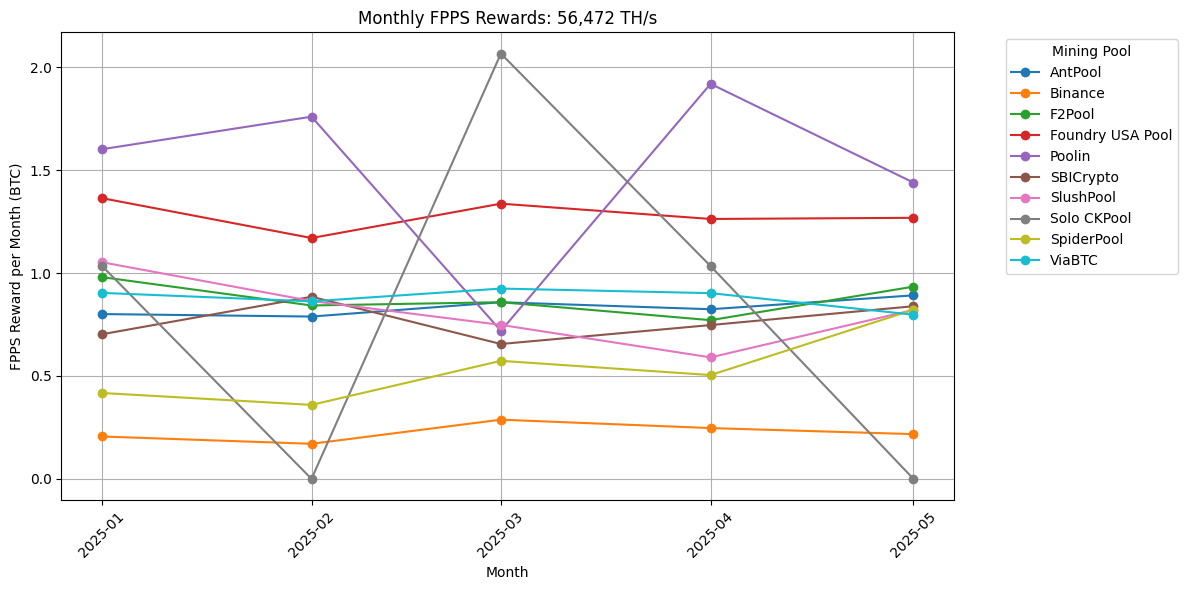

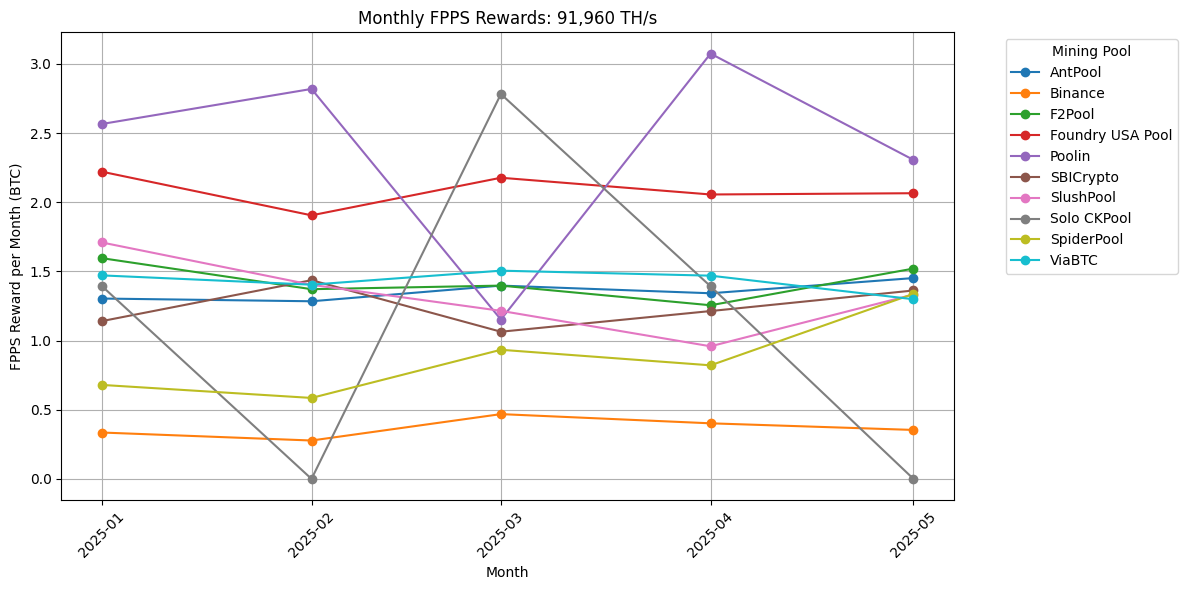

In [82]:
fpps_table.index = pd.to_datetime(fpps_table.index)

hashrate_labels = fpps_table.columns.levels[0]

for hashrate in hashrate_labels:
    plt.figure(figsize=(12, 6))
    subset = fpps_table[hashrate]
    
    for miner in subset.columns:
        plt.plot(fpps_table.index, subset[miner], marker='o', label=miner)
    
    plt.title(f"Monthly FPPS Rewards: {hashrate}")
    plt.xlabel("Month")
    plt.ylabel("FPPS Reward per Month (BTC)")
    plt.xticks(ticks=fpps_table.index, labels=fpps_table.index.strftime('%Y-%m'), rotation=45)
    plt.grid(True)
    plt.legend(title="Mining Pool", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


Based on the results, it seems that the greatest FPPS Rewards per Month would come from Poolin (slightly more volatile) or Foundry USA Pool (more consistent). It is advised to take into account that Poolin has a significantly smaller hashrate than most other pools. If looking for maximum stability, besides Foundry USA Pool, three alternative options that may be considered are ViaBTC, F2Pool, and/or AntPool.